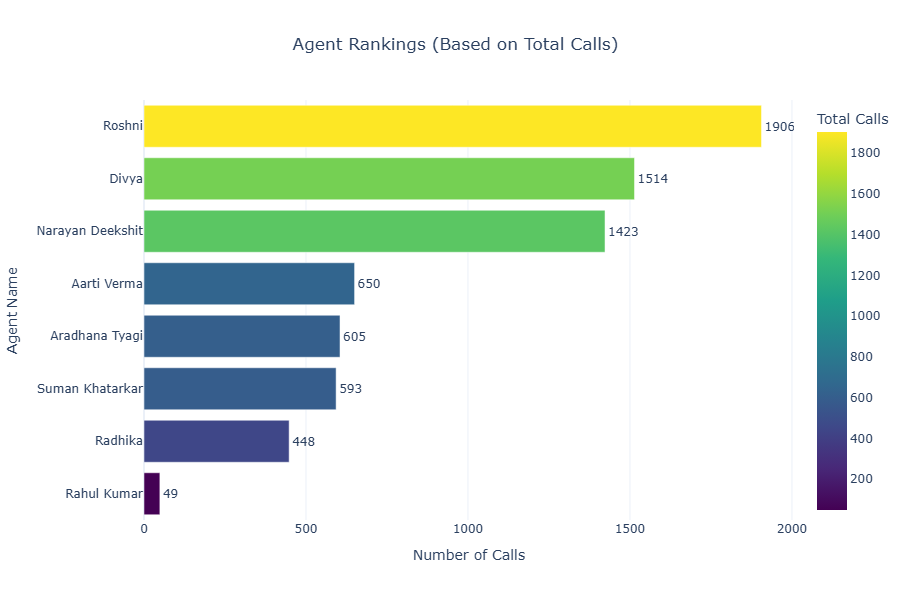

In [ ]:
import pandas as pd
import plotly.express as px


sheet_id = input("Enter Google Sheet ID: ")
sheet_name = input("Enter Sheet Name: ")
gid = input("Enter GID")
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"

df = pd.read_csv(url)



agent_rankings = (
    df.groupby("Master Agent Name")["Call Id"]
      .count()
      .reset_index(name="Total Calls")
)



agent_rankings = agent_rankings.sort_values(
    by="Total Calls",
    ascending=False
)


agent_rankings["Rank"] = range(1, len(agent_rankings) + 1)



fig = px.bar(
    agent_rankings,
    x="Total Calls",
    y="Master Agent Name",
    orientation="h",
    color="Total Calls",
    color_continuous_scale="Viridis",
    text="Total Calls",
    hover_data=["Rank"],
    title="Agent Rankings (Based on Total Calls)"
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    template="plotly_white",
    height=600,
    width=900,
    title_x=0.5,
    xaxis_title="Number of Calls",
    yaxis_title="Agent Name",
    yaxis=dict(categoryorder="total ascending")
)

fig.show()